# Controlled Trajectory Examples: 3 — Planar Quadrotor

This is the **third example** in the four-part controlled-trajectory
progression.  The second example
introduced a multi-agent stacked system.  Here we stay with a single agent
but add the physical coupling that arises in a real robotic platform: the
**planar quadrotor**.

## Physical system

A planar (2-D) quadrotor has position $(y, z)$ in the vertical plane,
roll angle $\phi$, and the corresponding velocities.  The two motor
thrusts $u_1$ and $u_2$ provide total thrust and differential torque.

$$
x = \begin{bmatrix} y \\ z \\ \phi \\ \dot{y} \\ \dot{z} \\ \dot{\phi}
    \end{bmatrix}, \qquad
u = \begin{bmatrix} u_1 \\ u_2 \end{bmatrix}.
$$

Linearizing around the hover equilibrium
$(y, z, \phi, \dot{y}, \dot{z}, \dot{\phi}) = 0$,
$u_1 = u_2 = mg/2$ and using small-angle approximations, gives the
linear time-invariant model

$$
A_c = \begin{bmatrix}
  0 & 0 & 0 & 1 & 0 & 0 \\
  0 & 0 & 0 & 0 & 1 & 0 \\
  0 & 0 & 0 & 0 & 0 & 1 \\
  0 & 0 & -g & 0 & 0 & 0 \\
  0 & 0 & 0 & 0 & 0 & 0 \\
  0 & 0 & 0 & 0 & 0 & 0
\end{bmatrix},
\qquad
B_c = \begin{bmatrix}
  0 & 0 \\ 0 & 0 \\ 0 & 0 \\ 0 & 0 \\
  1/m & 1/m \\
  \ell/(2I) & -\ell/(2I)
\end{bmatrix},
$$

where $g = 9.81\,\text{m/s}^2$, $m$ is the total mass, $I$ the moment
of inertia about the roll axis, and $\ell$ the half-arm length.  The
coupling term $-g\,\phi$ in the $\ddot{y}$ row captures the lateral
acceleration due to roll.

**References:**
- Mahony, Müller & Ganguli (2012), "A non-linear observer for attitude estimation
  of a fixed-wing unmanned aerial vehicle without GPS measurements",
  *Control Engineering Practice*.
- Mueller & D'Andrea (2013), "Stability and control of a quadrocopter despite
  the complete loss of one, two, or three propellers",
  *ICRA 2014*.

In [1]:
using CellularSheaves
using LinearAlgebra
using BlockArrays
using Plots
using SparseArrays

## Step 1: Physical parameters and hover linearization

In [2]:
g  = 9.81    # gravitational acceleration (m/s²)
m  = 0.5     # vehicle mass (kg)
I_quad = 0.01    # moment of inertia about roll axis (kg·m²)
ℓ  = 0.25    # half arm length (m)

0.25

The coupling $-g$ in the (4,3) entry of $A_c$ is the hallmark of
the hover linearization: lateral acceleration is proportional to roll angle.

In [3]:
Ac = [0.0  0.0   0.0   1.0  0.0  0.0;
      0.0  0.0   0.0   0.0  1.0  0.0;
      0.0  0.0   0.0   0.0  0.0  1.0;
      0.0  0.0  -g     0.0  0.0  0.0;
      0.0  0.0   0.0   0.0  0.0  0.0;
      0.0  0.0   0.0   0.0  0.0  0.0]

Bc = [0.0           0.0;
      0.0           0.0;
      0.0           0.0;
      0.0           0.0;
      1.0/m         1.0/m;
      ℓ/(2.0*I_quad)  -ℓ/(2.0*I_quad)]

println("State dim n = ", size(Ac, 1))
println("Control dim m = ", size(Bc, 2))

State dim n = 6
Control dim m = 2


## Step 2: Build the ControlledTrajectorySheaf

In [4]:
h = 0.05    # sample period (seconds) — short step for fast quadrotor dynamics
k = 12      # number of time steps (0.6 s total horizon)

F  = EuclideanSheaf{Float64}(fill(6, 1))   # one vertex, 6D stalk
ts = ControlledTrajectorySheaf(F, Ac, Bc, h, k)

ControlledTrajectorySheaf{Float64}(12, 0.05, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 1.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0; 0.0 0.0; … ; 2.0 2.0; 12.5 -12.5], [1.0 0.0 … 0.0 -0.000204375; 0.0 1.0 … 0.049999999999999996 0.0; … ; 0.0 0.0 … 1.0 0.0; 0.0 0.0 … 0.0 1.0], [-3.193359375e-5 3.193359375e-5; 0.0024999999999999996 0.0024999999999999996; … ; 0.09999999999999999 0.09999999999999999; 0.625 -0.625], A network sheaf with 14 vertex stalks and 13 edge stalks.
, 6, 2)

## Step 3: Fix endpoint states

We execute a short lateral manoeuvre: move 0.5 m in the $y$-direction while
returning to hover at the end.  The $z$-position and roll angle start and
end at zero.

In [5]:
x1  = zeros(6)                    # start at hover
xk1 = [0.5, 0.0, 0.0, 0.0, 0.0, 0.0]   # 0.5 m lateral displacement, back to hover

6-element Vector{Float64}:
 0.5
 0.0
 0.0
 0.0
 0.0
 0.0

## Step 4: Assemble the LQR objective

Penalize lateral position and roll angle more heavily in the terminal cost
to discourage residual roll at landing.

In [6]:
n = ts.state_dim
m_ctrl = ts.control_dim

Q  = Diagonal([1.0, 1.0, 2.0, 0.5, 0.5, 0.5])   # state running cost
Ru = Matrix{Float64}(I, m_ctrl, m_ctrl)            # control cost
Qf = Diagonal([10.0, 10.0, 20.0, 1.0, 1.0, 1.0]) # heavier terminal penalty

H, f, _ = lqr_objective(ts, Matrix(Q), Ru; Qf=Matrix(Qf))

(sparse([1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  93, 94, 95, 96, 97, 98, 99, 100, 101, 102], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  93, 94, 95, 96, 97, 98, 99, 100, 101, 102], [1.0, 1.0, 2.0, 0.5, 0.5, 0.5, 1.0, 1.0, 2.0, 0.5  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 102, 102), [-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0  …  -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0], 0.0)

Visualize the block-diagonal cost Hessian H.
State weights Q (×k running blocks, Qf on terminal) and control weight Ru
(×k blocks) are placed on the block diagonal.  The non-uniform Q/Qf
weighting (heavier roll penalty) is visible in alternating stripe intensities
on the state-block diagonal.

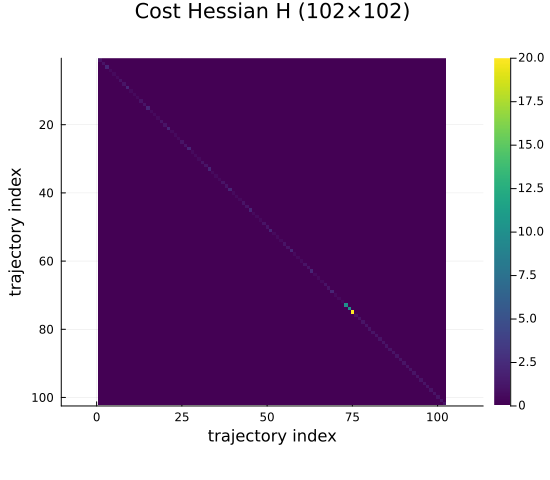

In [7]:
p_H = heatmap(Matrix(H);
    color=:viridis, colorbar=true,
    title="Cost Hessian H ($(size(H,1))×$(size(H,2)))",
    xlabel="trajectory index", ylabel="trajectory index",
    yflip=true, aspect_ratio=:equal, size=(550, 480))
p_H

## Step 5: Solve for the optimal trajectory

In [8]:
z_opt, α_opt, z_p, null_basis = optimal_control_trajectory(ts, x1, xk1, H, f)

println("Free parameters r = ", size(null_basis, 2))
println("All entries finite: ", all(isfinite, Array(z_opt)))

Free parameters r = 9
All entries finite: true


## Step 6: State and control time-series

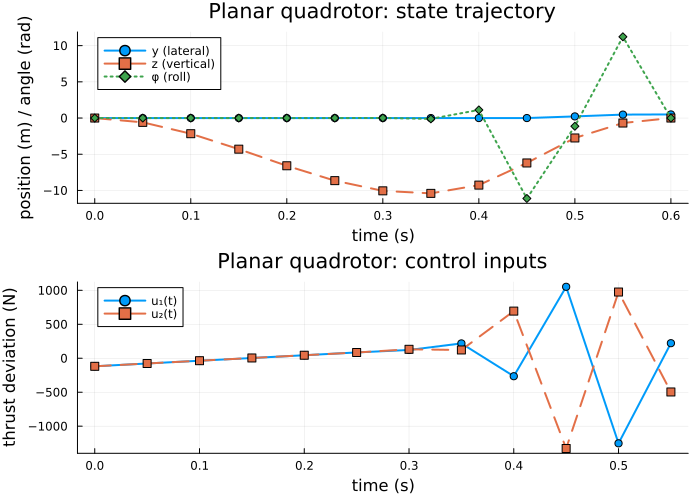

In [9]:
times_state   = h .* (0:k)
times_control = h .* (0:k-1)

y_traj   = [Array(z_opt[Block(t)])[1] for t in 1:k+1]
z_traj   = [Array(z_opt[Block(t)])[2] for t in 1:k+1]
phi_traj = [Array(z_opt[Block(t)])[3] for t in 1:k+1]
u1_traj  = [Array(z_opt[Block(k+1+t)])[1] for t in 1:k]
u2_traj  = [Array(z_opt[Block(k+1+t)])[2] for t in 1:k]

p_state = plot(times_state, y_traj;
    lw=2, marker=:circle, label="y (lateral)",
    xlabel="time (s)", ylabel="position (m) / angle (rad)",
    title="Planar quadrotor: state trajectory")
plot!(p_state, times_state, z_traj;
    lw=2, marker=:square, linestyle=:dash, label="z (vertical)")
plot!(p_state, times_state, phi_traj;
    lw=2, marker=:diamond, linestyle=:dot, label="φ (roll)")

p_ctrl = plot(times_control, u1_traj;
    lw=2, marker=:circle, label="u₁(t)",
    xlabel="time (s)", ylabel="thrust deviation (N)",
    title="Planar quadrotor: control inputs")
plot!(p_ctrl, times_control, u2_traj;
    lw=2, marker=:square, linestyle=:dash, label="u₂(t)")

quadrotor_ts_plot = plot(p_state, p_ctrl; layout=(2, 1), size=(700, 500))
quadrotor_ts_plot

## Step 7: Trajectory in the physical plane and pitch angle

The vehicle follows a curved arc in the $(y, z)$-plane as it accelerates
laterally.  Roll couples lateral and vertical motion: to move in the
$y$-direction, the vehicle first tilts (positive $\phi$), which redirects
thrust horizontally.

Two panels are shown:
- **Left** — the spatial trajectory $(y(t), z(t))$ in the vertical plane,
  with time encoded as marker size (small at start, large at end).
- **Right** — the roll angle $\phi(t)$ as a function of time, showing the
  pitch-up / pitch-down manoeuvre.

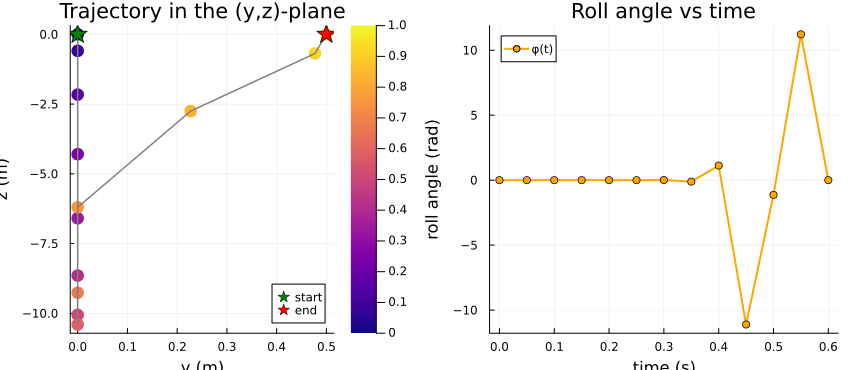

In [10]:
t_idx  = 1:k+1
t_norm = range(0.0, 1.0; length=k+1)

p_plane = scatter(y_traj, z_traj;
    marker_z=t_norm, color=:plasma, colorbar=true,
    label="", xlabel="y (m)", ylabel="z (m)",
    title="Trajectory in the (y,z)-plane",
    markerstrokewidth=0, markersize=7)
plot!(p_plane, y_traj, z_traj; lw=1.5, color=:gray, label="")
scatter!(p_plane, [y_traj[1]], [z_traj[1]]; color=:green, markersize=10,
    label="start", markershape=:star5)
scatter!(p_plane, [y_traj[end]], [z_traj[end]]; color=:red, markersize=10,
    label="end", markershape=:star5)

p_phi = plot(times_state, phi_traj;
    lw=2, color=:orange, marker=:circle, label="φ(t)",
    xlabel="time (s)", ylabel="roll angle (rad)",
    title="Roll angle vs time")

quadrotor_traj_plot = plot(p_plane, p_phi; layout=(1, 2), size=(850, 370))
quadrotor_traj_plot

## Step 8: Animated trajectory (physical plane on a loop)

Each frame adds one more time step to the path in the $(y, z)$-plane.

[ Info: Saved animation to /tmp/jl_4v4JCpGRUJ.gif


Plots.AnimatedGif("/tmp/jl_4v4JCpGRUJ.gif")
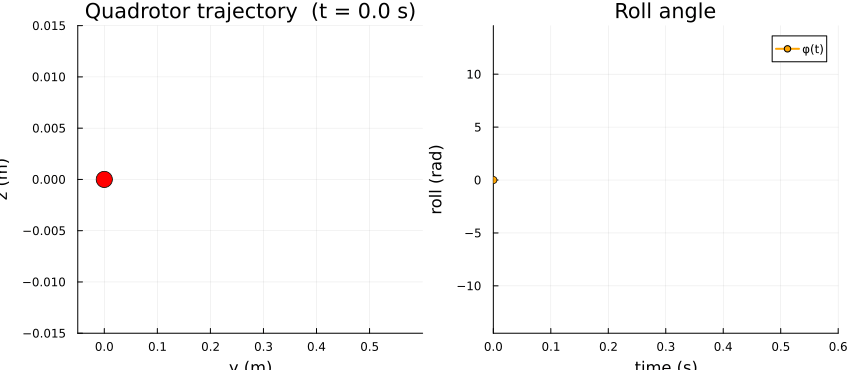

In [11]:
phi_min = minimum(phi_traj)
phi_max = maximum(phi_traj)
phi_pad = max(abs(phi_min), abs(phi_max)) * 0.3

anim = @animate for i in 1:k+1
    p1 = plot(y_traj[1:i], z_traj[1:i];
        lw=2, color=:royalblue, label="",
        xlabel="y (m)", ylabel="z (m)",
        title="Quadrotor trajectory  (t = $(round(times_state[i]; digits=2)) s)",
        xlims=(-0.05, 0.6), ylims=(-0.015, 0.015))
    scatter!(p1, [y_traj[i]], [z_traj[i]];
        color=:red, markersize=9, markershape=:circle, label="")
    p2 = plot(times_state[1:i], phi_traj[1:i];
        lw=2, color=:orange, marker=:circle, label="φ(t)",
        xlabel="time (s)", ylabel="roll (rad)",
        title="Roll angle",
        xlims=(0, k * h), ylims=(phi_min - phi_pad, phi_max + phi_pad))
    plot(p1, p2; layout=(1, 2), size=(850, 370))
end
quadrotor_anim = gif(anim; fps=6)
quadrotor_anim

## Verification (converted to warnings)

Endpoint checks – issue warnings instead of failing the build.

In [12]:
if !(Array(z_opt[Block(1)]) ≈ x1)
    @warn "Initial state not satisfied"
end
if !(isapprox(Array(z_opt[Block(k + 1)]), xk1; atol=1e-8))
    @warn "Terminal state not satisfied"
end
if !all(isfinite, Array(z_opt))
    @warn "Trajectory contains non-finite values"
end

Dynamics consistency – report any violations as warnings.

In [13]:
for t in 1:k
    xt  = Array(z_opt[Block(t)])
    xt1 = Array(z_opt[Block(t + 1)])
    ut  = Array(z_opt[Block(k + 1 + t)])
    resid = norm(ts.Ad * xt + ts.Bd * ut - xt1)
    if resid ≥ 1e-9
        @warn "Dynamics violated at step $t (residual = $resid)"
    end
end
println("All endpoint and dynamics checks completed (warnings, if any, were shown above).")

┌ Warning: Dynamics violated at step 1 (residual = 2.4355791039879535e-8)
└ @ Main.var"##346" ~/work/CellularSheaves.jl/CellularSheaves.jl/docs/src/generated/control/controlled_planar_quadrotor.ipynb:7
┌ Warning: Dynamics violated at step 2 (residual = 1.214440667469714e-8)
└ @ Main.var"##346" ~/work/CellularSheaves.jl/CellularSheaves.jl/docs/src/generated/control/controlled_planar_quadrotor.ipynb:7
┌ Warning: Dynamics violated at step 3 (residual = 1.4452711550264003e-8)
└ @ Main.var"##346" ~/work/CellularSheaves.jl/CellularSheaves.jl/docs/src/generated/control/controlled_planar_quadrotor.ipynb:7
┌ Warning: Dynamics violated at step 4 (residual = 1.4491264420718964e-8)
└ @ Main.var"##346" ~/work/CellularSheaves.jl/CellularSheaves.jl/docs/src/generated/control/controlled_planar_quadrotor.ipynb:7
┌ Warning: Dynamics violated at step 5 (residual = 1.4805365165594271e-8)
└ @ Main.var"##346" ~/work/CellularSheaves.jl/CellularSheaves.jl/docs/src/generated/control/controlled_planar_quadrotor

## What this example adds

Compared with the vehicle platoon, the planar quadrotor introduces:

- A **physically coupled** state space: the lateral acceleration is driven by
  the roll angle through the $-g\,\phi$ term in $A_c$.
- **Two control inputs** ($u_1$, $u_2$) whose sum and difference
  independently govern vertical thrust and roll torque.
- A **6-dimensional state**, requiring a more structured choice of $Q$ and
  $Q_f$ to balance position and angular degrees of freedom.

The next and final example, **Mass-Spring-Damper Chain**, returns to a
graph-coupled mechanical system that bridges toward sheaf-theoretic
network analysis.